# 📊 01. Comprehensive Exploratory Data Analysis (EDA) & Visual Analytics
**Project:** Cyberbullying Detection & Explainability System (MuRIL + SHAP / LIME)  
**Authors:** Deep Learning & NLP Engineering Team  

---

### 🎯 Purpose & Objectives of this Notebook
This notebook conducts an in-depth, rigorous Exploratory Data Analysis (EDA) on two primary datasets:
1. **Kaggle Cyberbullying Classification Dataset (`cyberbullying_tweets.csv`)**:
   - **47,692 tweets** labeled across 6 distinct categories: `age`, `gender`, `ethnicity`, `religion`, `other_cyberbullying`, and `not_cyberbullying`.
   - Used for **multi-class cyberbullying classification** and analyzing targeted linguistic abuse patterns.
2. **BullyExplain Dataset (`BullyExplain.xlsx`)**:
   - **6,436 Code-Mixed (Hinglish/Hindi/English) tweets** with multi-dimensional annotations:
     - Binary Bullying Label (`Bully` vs `Non_bully`)
     - Fine-grained target (`Relatives/Friends`, `Religion`, `Race`, `Gender`, etc.)
     - Emotional Tone (`Disgust`, `Ridicule`, `Anger`, `Joy`, `Sadness`, etc.)
     - Sarcasm indicator (`1` vs `0`)
     - **Word-Level Human Rationales (`Explaine`)** showing exactly *which words* triggered the annotators' bullying decision.

---

### 🧠 How to Use & Explain This Notebook (Interview / Viva Speaking Points)
- **Class Balance**: Understand whether classes are balanced or imbalanced.
- **Linguistic Markers**: Show how length, shouting (ALL CAPS), punctuation, hashtags, and mentions vary between cyberbullying and neutral tweets.
- **Discriminative Vocabulary**: Inspect Top Unigrams, Bigrams, and Word Clouds per category.
- **Explainability Preview (TF-IDF + Logistic Regression Coefficients)**: Demonstrate how linear models assign weights to specific abusive tokens, serving as a baseline bridge to deep learning (MuRIL) and SHAP.
- **BullyExplain Rationales**: Demonstrate how human-annotated rationales validate model attention and explainability.

## 1. Setup & Environment Configuration
Importing core data manipulation, natural language processing, modeling, and rich visualization libraries.

In [1]:
import os
import re
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Scikit-learn for baseline modeling & text processing
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# NLTK for text processing
import nltk
from nltk.corpus import stopwords

warnings.filterwarnings('ignore')

# Visual styling for rich, professional publication-quality charts
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
sns.set_palette("tab10")

print(" Libraries successfully imported.")

 Libraries successfully imported.


## 2. Dataset Ingestion & Initial Health Check
Let us load both datasets from `../data/raw/` and inspect their dimensions, missing values, and column schemas.

In [2]:
# Define file paths
kaggle_path = os.path.join('..', 'data', 'raw', 'cyberbullying_tweets.csv')
bully_path = os.path.join('..', 'data', 'raw', 'BullyExplain.xlsx')

# 1. Load Kaggle Cyberbullying Dataset
df_kaggle = pd.read_csv(kaggle_path)
print("=" * 60)
print(f" Kaggle Cyberbullying Dataset Loaded: {df_kaggle.shape[0]:,} rows, {df_kaggle.shape[1]} columns")
print("=" * 60)
display(df_kaggle.head())

# 2. Load BullyExplain Dataset
df_bully = pd.read_excel(bully_path)
print("\n" + "=" * 60)
print(f" BullyExplain Dataset Loaded: {df_bully.shape[0]:,} rows, {df_bully.shape[1]} columns")
print("=" * 60)
display(df_bully.head())

 Kaggle Cyberbullying Dataset Loaded: 47,692 rows, 2 columns


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying



 BullyExplain Dataset Loaded: 6,436 rows, 10 columns


,tweet,Bully_Label,Sentiment,Emotion_label,Sarcasm,Target,Explaine,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,#islamic #kuttiya @MamataOfficial ur pimps ki...,Bully,Negative,Disgust,No,Religion,{islamic {kuttiya ur pimps {killed an 85 yrs o...,Bully,Positive,NaN
1,@Harpreetmandai6 @realSukhiChahal @BJP4Punjab ...,Bully,Negative,Anger,No,Organization,Jadd Bengal ch dastaar lah k {kuttiya si udo t...,Non_bully,Negative,Joy
2,@RanaAyyub Yaa u do fake shame no one cares we...,Bully,Negative,Disgust,No,Religion,Yaa u do {fake {shame no one cares we cant acx...,Race,Neutral,Sadness
3,@StanningRubina @disha11parmar Rubina supporte...,Bully,Negative,Disgust,No,Gender,Rubina supporter talking about voice so funny ...,Religion,Yes,Fear
4,@aajtak Kuttiya k balatkar k paidais ko encoun...,Bully,Negative,Anger,No,Gender,{Kuttiya k {balatkar k {paidais ko {encounter ...,Gender,No,Surprise


### Data Quality & Missing Value Inspection

In [3]:
# Health Check: Missing values and duplicates in Kaggle Dataset
print("--- [Kaggle Dataset Health Check] ---")
print("Missing values per column:\n", df_kaggle.isnull().sum())
duplicates_kaggle = df_kaggle.duplicated(subset=['tweet_text']).sum()
print(f"\nDuplicate tweets in text column: {duplicates_kaggle:,} ({duplicates_kaggle / len(df_kaggle) * 100:.2f}%)")

# Health Check: Missing values in BullyExplain Dataset
print("\n--- [BullyExplain Dataset Health Check] ---")
print("Missing values per column:\n", df_bully.isnull().sum())
# Drop trailing unnamed columns if present
unnamed_cols = [c for c in df_bully.columns if 'Unnamed' in c]
if unnamed_cols:
    df_bully.drop(columns=unnamed_cols, inplace=True)
    print(f"Dropped trailing columns: {unnamed_cols}")

--- [Kaggle Dataset Health Check] ---
Missing values per column:
 tweet_text            0
cyberbullying_type    0
dtype: int64

Duplicate tweets in text column: 1,675 (3.51%)

--- [BullyExplain Dataset Health Check] ---
Missing values per column:
 tweet               1
Bully_Label        42
Sentiment          42
Emotion_label      50
Sarcasm            42
Target             60
Explaine            4
Unnamed: 7       6397
Unnamed: 8       6431
Unnamed: 9       6426
dtype: int64
Dropped trailing columns: ['Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']


## 3. Kaggle Dataset: Multi-Class Cyberbullying Deep Dive
The Kaggle dataset contains 6 target classes:
- **`religion`**: Targeted harassment based on faith, religious identity, or theological beliefs.
- **`age`**: Harassment targeted at younger people (school bullying, high school bullying).
- **`gender`**: Sexist, misogynistic, and sexually explicit verbal attacks.
- **`ethnicity`**: Racial slurs and xenophobic hate speech.
- **`other_cyberbullying`**: Generic abusive language, trolling, and flame wars that do not fall into specific identity buckets.
- **`not_cyberbullying`**: Benign tweets, normal discourse, news reporting, and TV commentary (e.g., `#MKR` tweets).

Let's check the class balance with rich visual plots.

,Tweet Count,Percentage (%)
cyberbullying_type,,
religion,7998,16.77
age,7992,16.76
gender,7973,16.72
ethnicity,7961,16.69
not_cyberbullying,7945,16.66
other_cyberbullying,7823,16.40


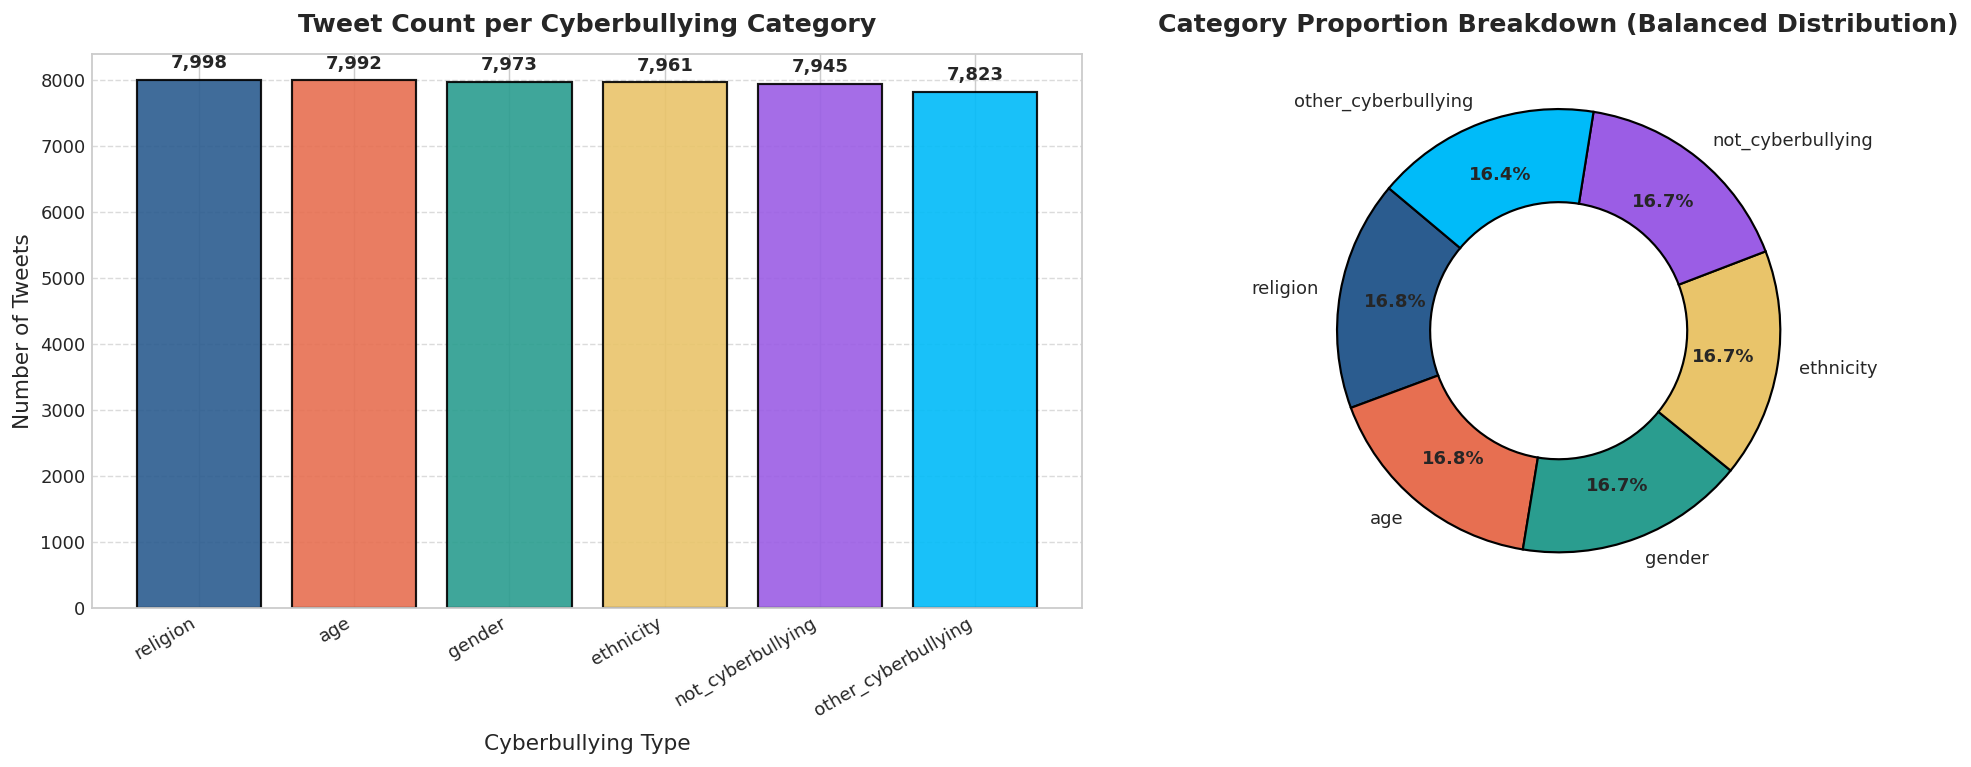

In [4]:
# Class distribution calculation
class_counts = df_kaggle['cyberbullying_type'].value_counts()
class_pcts = df_kaggle['cyberbullying_type'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Tweet Count': class_counts,
    'Percentage (%)': class_pcts.round(2)
})
display(summary_df)

# Rich Visual Plot: Bar + Donut Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Custom vibrant color palette
palette = ['#2b5c8f', '#e76f51', '#2a9d8f', '#e9c46a', '#9b5de5', '#00bbf9']
bars = ax1.bar(class_counts.index, class_counts.values, color=palette, edgecolor='black', linewidth=1.2, alpha=0.9)
ax1.set_title("Tweet Count per Cyberbullying Category", fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel("Cyberbullying Type", fontsize=12, labelpad=8)
ax1.set_ylabel("Number of Tweets", fontsize=12)
ax1.set_xticklabels(class_counts.index, rotation=30, ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 120, f'{int(yval):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Donut Chart with shadow & clean percentage callouts
wedges, texts, autotexts = ax2.pie(
    class_pcts, 
    labels=class_pcts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=palette,
    wedgeprops=dict(width=0.42, edgecolor='black', linewidth=1.2),
    pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
ax2.set_title("Category Proportion Breakdown (Balanced Distribution)", fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

💡 **Key Insight on Class Balance:**
> The Kaggle dataset is **almost perfectly balanced**, with roughly ~7,900 to ~8,000 tweets per class (~16.6% each). This means models trained on this dataset will **not suffer from severe class imbalance bias**, making macro-averaged metrics (Macro F1-score) directly comparable.

### 3.2 Text Complexity & Linguistic Feature Engineering
We extract structural metadata features from each tweet:
1. `char_count`: Total character length of the tweet.
2. `word_count`: Number of whitespace-separated tokens.
3. `avg_word_len`: Average characters per word.
4. `hashtag_count`: Count of `#` symbols.
5. `mention_count`: Count of `@` user tags.
6. `caps_ratio`: Percentage of uppercase characters (indicative of shouting/flaming).
7. `punct_count`: Count of punctuation marks (e.g. `!`, `?`).

In [5]:
# Feature engineering for text metadata
df_kaggle['char_count'] = df_kaggle['tweet_text'].apply(len)
df_kaggle['word_count'] = df_kaggle['tweet_text'].apply(lambda x: len(x.split()))
df_kaggle['avg_word_len'] = df_kaggle['char_count'] / (df_kaggle['word_count'] + 1e-5)
df_kaggle['hashtag_count'] = df_kaggle['tweet_text'].apply(lambda x: len(re.findall(r'#\w+', x)))
df_kaggle['mention_count'] = df_kaggle['tweet_text'].apply(lambda x: len(re.findall(r'@\w+', x)))
df_kaggle['caps_ratio'] = df_kaggle['tweet_text'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1e-5))
df_kaggle['punct_count'] = df_kaggle['tweet_text'].apply(lambda x: sum(1 for c in x if c in string.punctuation))

# Display Aggregated Stats per Class
stats_per_class = df_kaggle.groupby('cyberbullying_type')[[
    'char_count', 'word_count', 'avg_word_len', 'hashtag_count', 'mention_count', 'caps_ratio', 'punct_count'
]].mean().round(2)

print("--- Mean Feature Values by Cyberbullying Category ---")
display(stats_per_class)

--- Mean Feature Values by Cyberbullying Category ---


,char_count,word_count,avg_word_len,hashtag_count,mention_count,caps_ratio,punct_count
cyberbullying_type,,,,,,,
age,173.54,32.37,5.41,0.09,0.06,0.04,4.34
ethnicity,139.32,24.89,5.75,0.14,0.62,0.10,5.93
gender,136.42,23.54,6.08,0.34,0.57,0.06,6.41
not_cyberbullying,83.11,13.64,6.46,0.41,0.78,0.08,4.99
other_cyberbullying,85.71,14.10,6.68,0.21,0.86,0.08,5.32
religion,198.00,33.42,6.09,0.23,0.52,0.05,6.79


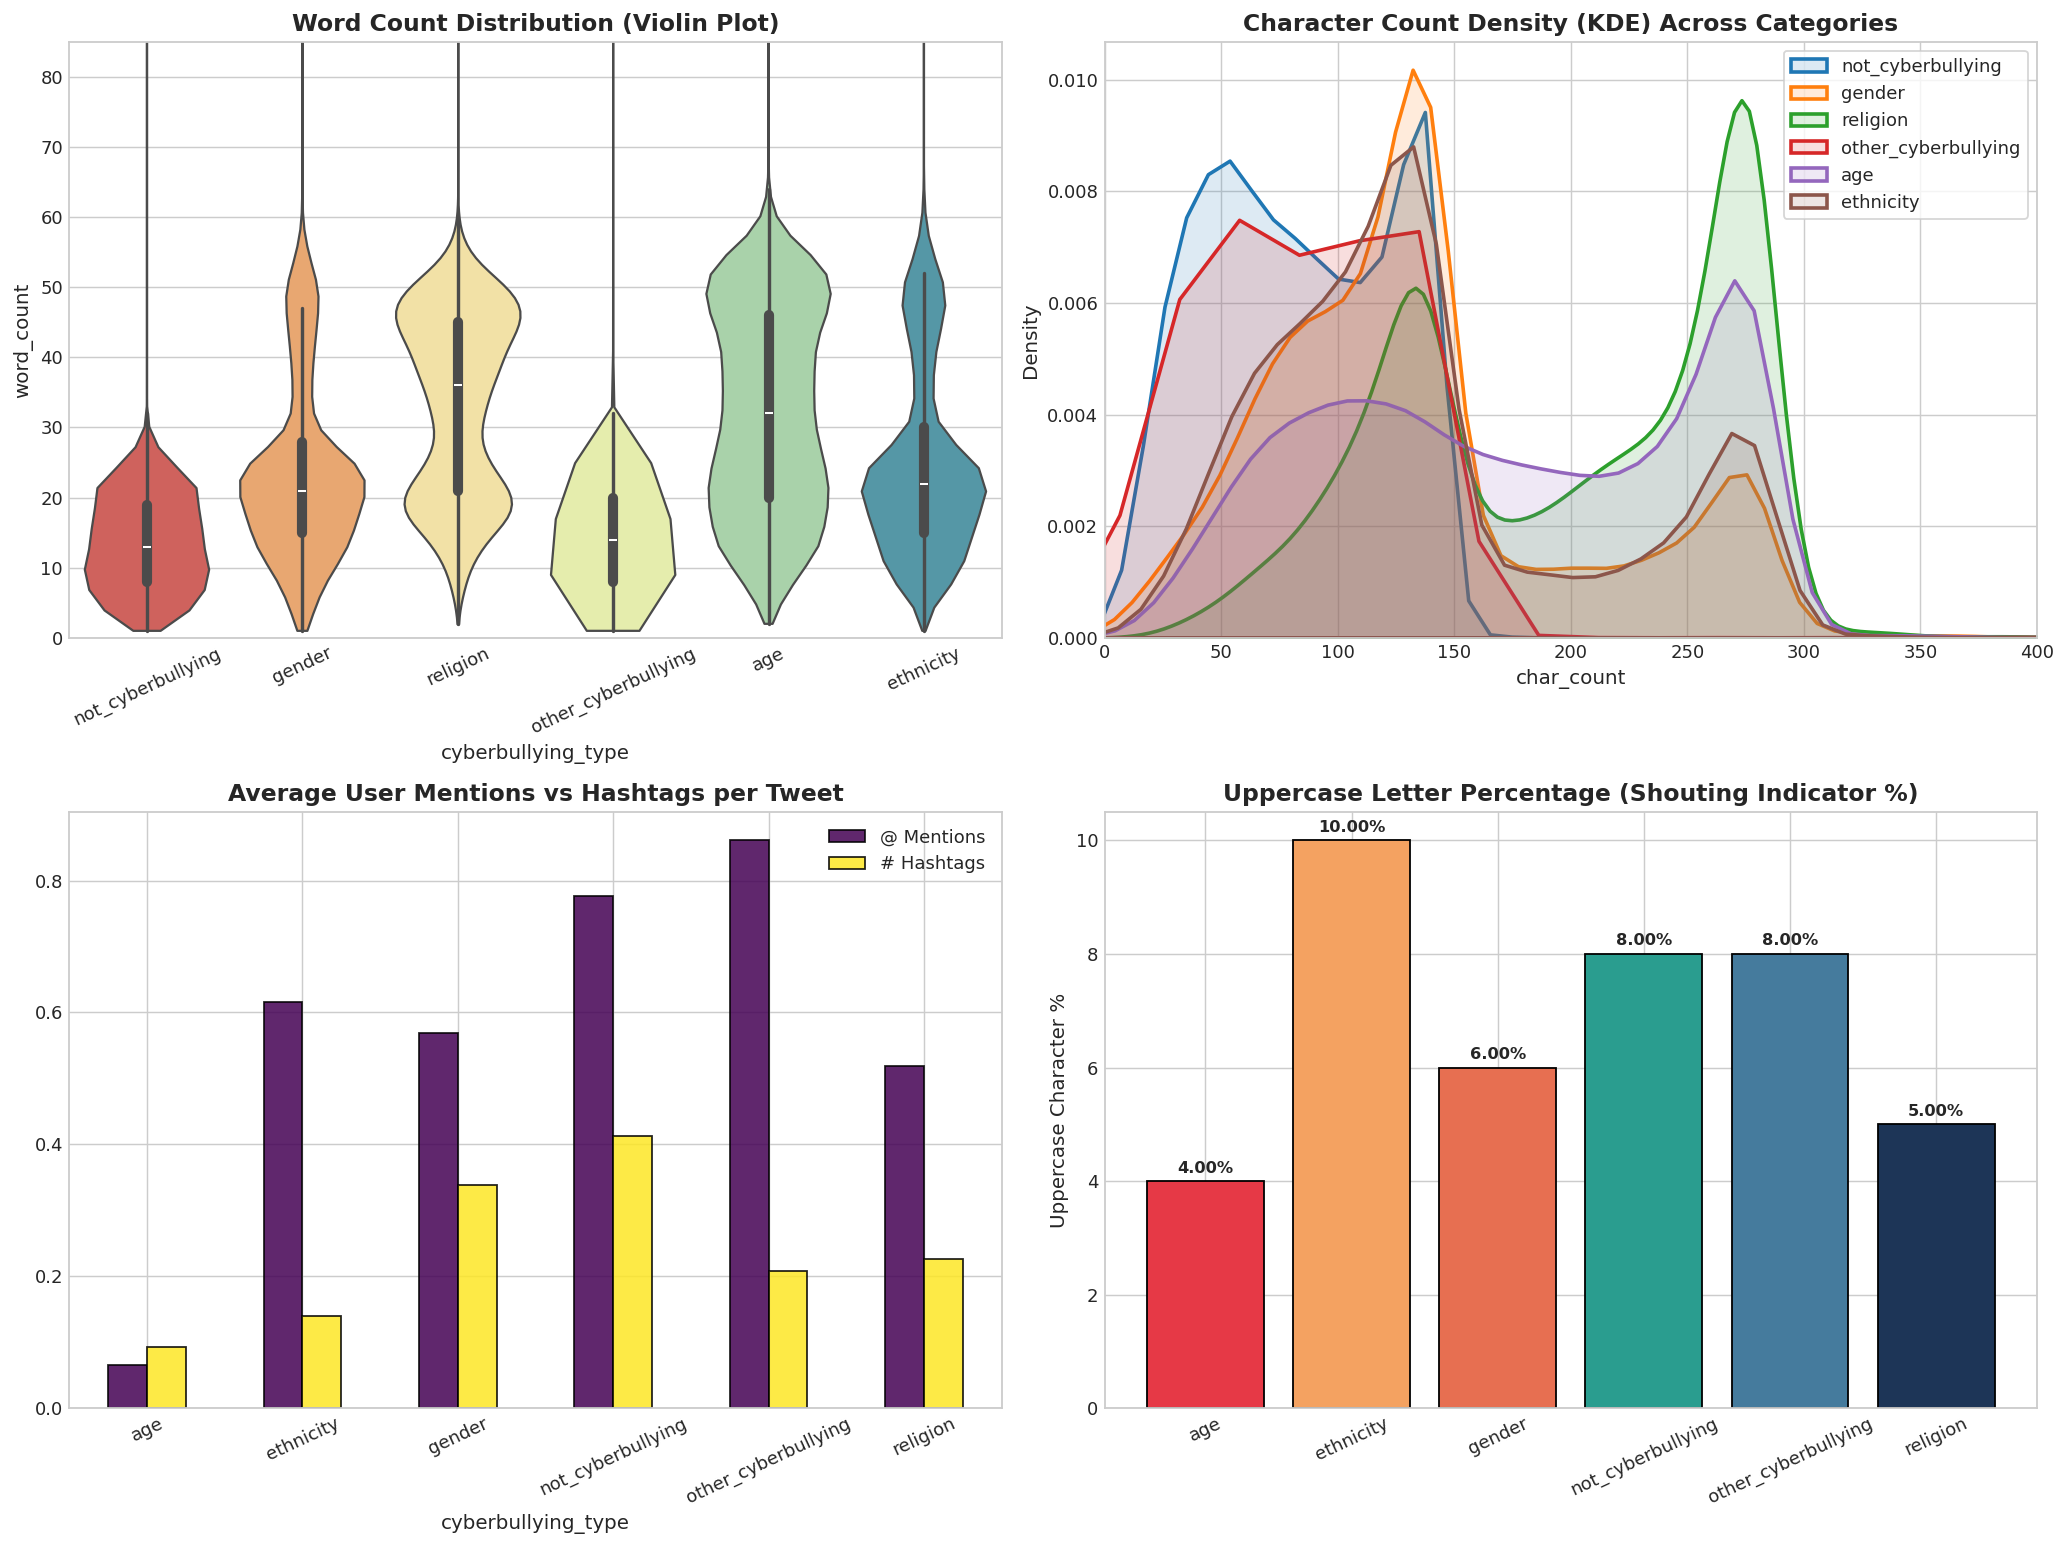

In [6]:
# Visualizing Text Length & Complexity (Violin Plots + KDE + Feature Comparisons)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Violin Plot of Word Counts per Category
sns.violinplot(data=df_kaggle, x='cyberbullying_type', y='word_count', ax=axes[0, 0], palette="Spectral", cut=0)
axes[0, 0].set_title("Word Count Distribution (Violin Plot)", fontsize=13, fontweight='bold')
axes[0, 0].set_ylim(0, 85)
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=25)

# 2. Character Count KDE Density
for cat in df_kaggle['cyberbullying_type'].unique():
    subset = df_kaggle[df_kaggle['cyberbullying_type'] == cat]
    sns.kdeplot(subset['char_count'], ax=axes[0, 1], label=cat, fill=True, alpha=0.15, linewidth=2)
axes[0, 1].set_title("Character Count Density (KDE) Across Categories", fontsize=13, fontweight='bold')
axes[0, 1].set_xlim(0, 400)
axes[0, 1].legend(loc='upper right', frameon=True)

# 3. Mention Count (@user) vs Hashtags (#tag) Grouped Bar Chart
grouped_feats = df_kaggle.groupby('cyberbullying_type')[['mention_count', 'hashtag_count']].mean()
grouped_feats.plot(kind='bar', ax=axes[1, 0], colormap='viridis', edgecolor='black', alpha=0.85)
axes[1, 0].set_title("Average User Mentions vs Hashtags per Tweet", fontsize=13, fontweight='bold')
axes[1, 0].set_xticklabels(grouped_feats.index, rotation=25)
axes[1, 0].legend(["@ Mentions", "# Hashtags"])

# 4. Caps Ratio (Shouting / Aggression)
bars4 = axes[1, 1].bar(
    stats_per_class.index, 
    stats_per_class['caps_ratio'] * 100, 
    color=['#e63946', '#f4a261', '#e76f51', '#2a9d8f', '#457b9d', '#1d3557'],
    edgecolor='black'
)
axes[1, 1].set_title("Uppercase Letter Percentage (Shouting Indicator %)", fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel("Uppercase Character %")
axes[1, 1].set_xticklabels(stats_per_class.index, rotation=25)
for bar in bars4:
    yval = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, yval + 0.15, f"{yval:.2f}%", ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

💡 **Key Linguistic Takeaways:**
1. **Length Differences**: Bullying tweets under `religion` and `ethnicity` tend to be significantly longer and elaborate (arguing theology/ideology or long rants), whereas `gender` and `age` tweets are often sharper and more direct.
2. **Mentions (`@user`)**: `gender` and `not_cyberbullying` categories have high user mention counts. In `not_cyberbullying`, mentions reflect social chatter or replying to friends/shows; in `gender` and `other_cyberbullying`, mentions signify direct targeted harassment.
3. **Uppercase Ratio**: High uppercase ratios often correlate with aggressive flame tweets and toxic yelling.

### 3.3 Qualitative Comparison: `not_cyberbullying` vs Bullying Categories
Comparing raw tweets helps us intuitively see why models distinguish neutral tweets from abusive categories.

In [7]:
def display_sample_comparison(df, n_samples=3):
    categories = ['age', 'gender', 'ethnicity', 'religion', 'other_cyberbullying']
    
    print("=" * 100)
    print("🔍 QUALITATIVE COMPARISON: Neutral Tweets vs Targeted Cyberbullying Tweets")
    print("=" * 100)
    
    neutral_samples = df[df['cyberbullying_type'] == 'not_cyberbullying']['tweet_text'].sample(n_samples, random_state=42).tolist()
    
    for cat in categories:
        cat_samples = df[df['cyberbullying_type'] == cat]['tweet_text'].sample(n_samples, random_state=42).tolist()
        print(f"\n📌 [CATEGORY COMPARISON: 'not_cyberbullying' vs '{cat.upper()}']")
        print("-" * 100)
        for i in range(n_samples):
            print(f"Sample #{i+1}:")
            print(f"  🟢 NOT_CYBERBULLYING : {neutral_samples[i].strip()[:110]}...")
            print(f"  🔴 {cat.upper():18}: {cat_samples[i].strip()[:110]}...")
            print()

display_sample_comparison(df_kaggle, n_samples=2)

🔍 QUALITATIVE COMPARISON: Neutral Tweets vs Targeted Cyberbullying Tweets

📌 [CATEGORY COMPARISON: 'not_cyberbullying' vs 'AGE']
----------------------------------------------------------------------------------------------------
Sample #1:
  🟢 NOT_CYBERBULLYING : RT @goodfoodAU: A restaurant AND a cookbook for #mykitchenrules twins Helena and Vikki. #mkr http://t.co/jopkw...
  🔴 AGE               : Every single one is a girl that would have bullied me in high school....

Sample #2:
  🟢 NOT_CYBERBULLYING : @Qoloob4 @Vandaliser @sajid_fairooz @IsraeliRegime I don't care about an idiot with an absurd opinion....
  🔴 AGE               : that post ab kpop stans going to school together and everyone saying theyre gonna bully armys in the replies.....


📌 [CATEGORY COMPARISON: 'not_cyberbullying' vs 'GENDER']
----------------------------------------------------------------------------------------------------
Sample #1:
  🟢 NOT_CYBERBULLYING : RT @goodfoodAU: A restaurant AND a cookbook for #

### 3.4 Vocabulary & N-Gram Frequency Analysis
Let us clean basic punctuation, remove standard English stopwords, and examine the most frequent unigrams and bigrams for each category.

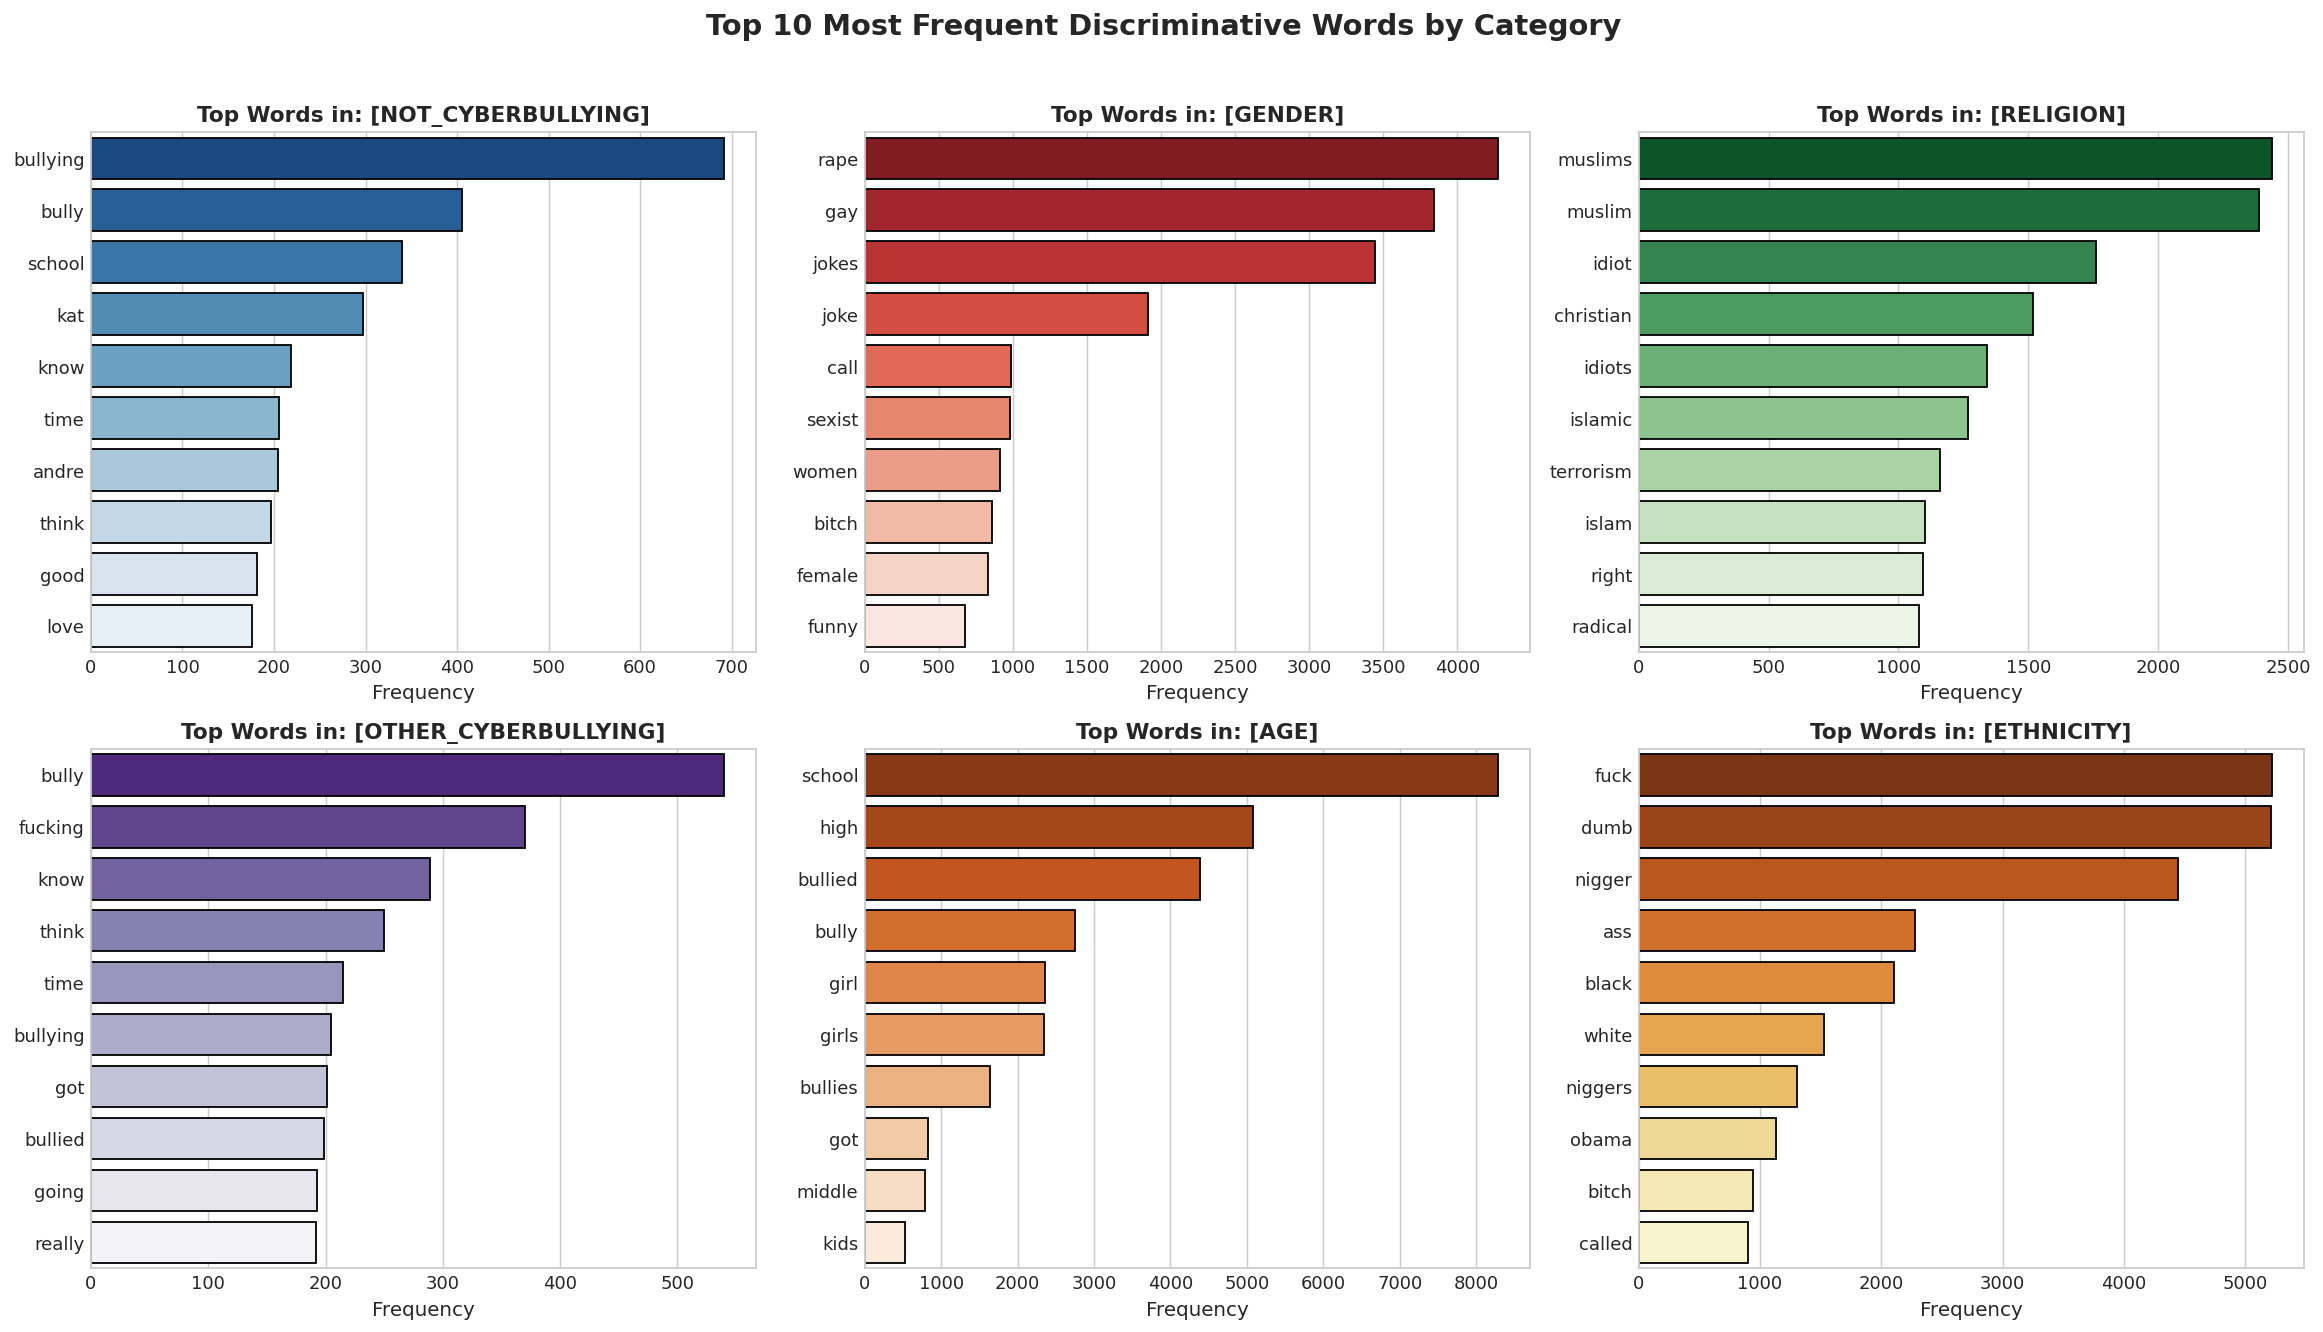

In [8]:
# Download stopwords if not available
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))
# Additional domain noise stopwords
custom_stops = stop_words.union({'http', 'https', 'co', 'rt', 'amp', 'u', 'ur', 'like', 'get', 'would', 'one', 'dont', 'people'})

def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    tokens = re.findall(r'\b[a-z]{3,}\b', text)
    return [w for w in tokens if w not in custom_stops]

# Compute top words per category
categories = df_kaggle['cyberbullying_type'].unique()
top_words_dict = {}

for cat in categories:
    cat_texts = df_kaggle[df_kaggle['cyberbullying_type'] == cat]['tweet_text']
    all_tokens = []
    for t in cat_texts:
        all_tokens.extend(clean_and_tokenize(t))
    top_words_dict[cat] = Counter(all_tokens).most_common(10)

# Plotting Top 10 Words per Category in a 2x3 Grid with color gradients
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

color_palettes = ['Blues_r', 'Reds_r', 'Greens_r', 'Purples_r', 'Oranges_r', 'YlOrBr_r']

for i, cat in enumerate(categories):
    words, counts = zip(*top_words_dict[cat])
    sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette=color_palettes[i], edgecolor='black')
    axes[i].set_title(f"Top Words in: [{cat.upper()}]", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Frequency")

plt.suptitle("Top 10 Most Frequent Discriminative Words by Category", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Word Cloud Visualizations per Cyberbullying Category
Word clouds provide an immediate visual signature of each category's lexical themes.

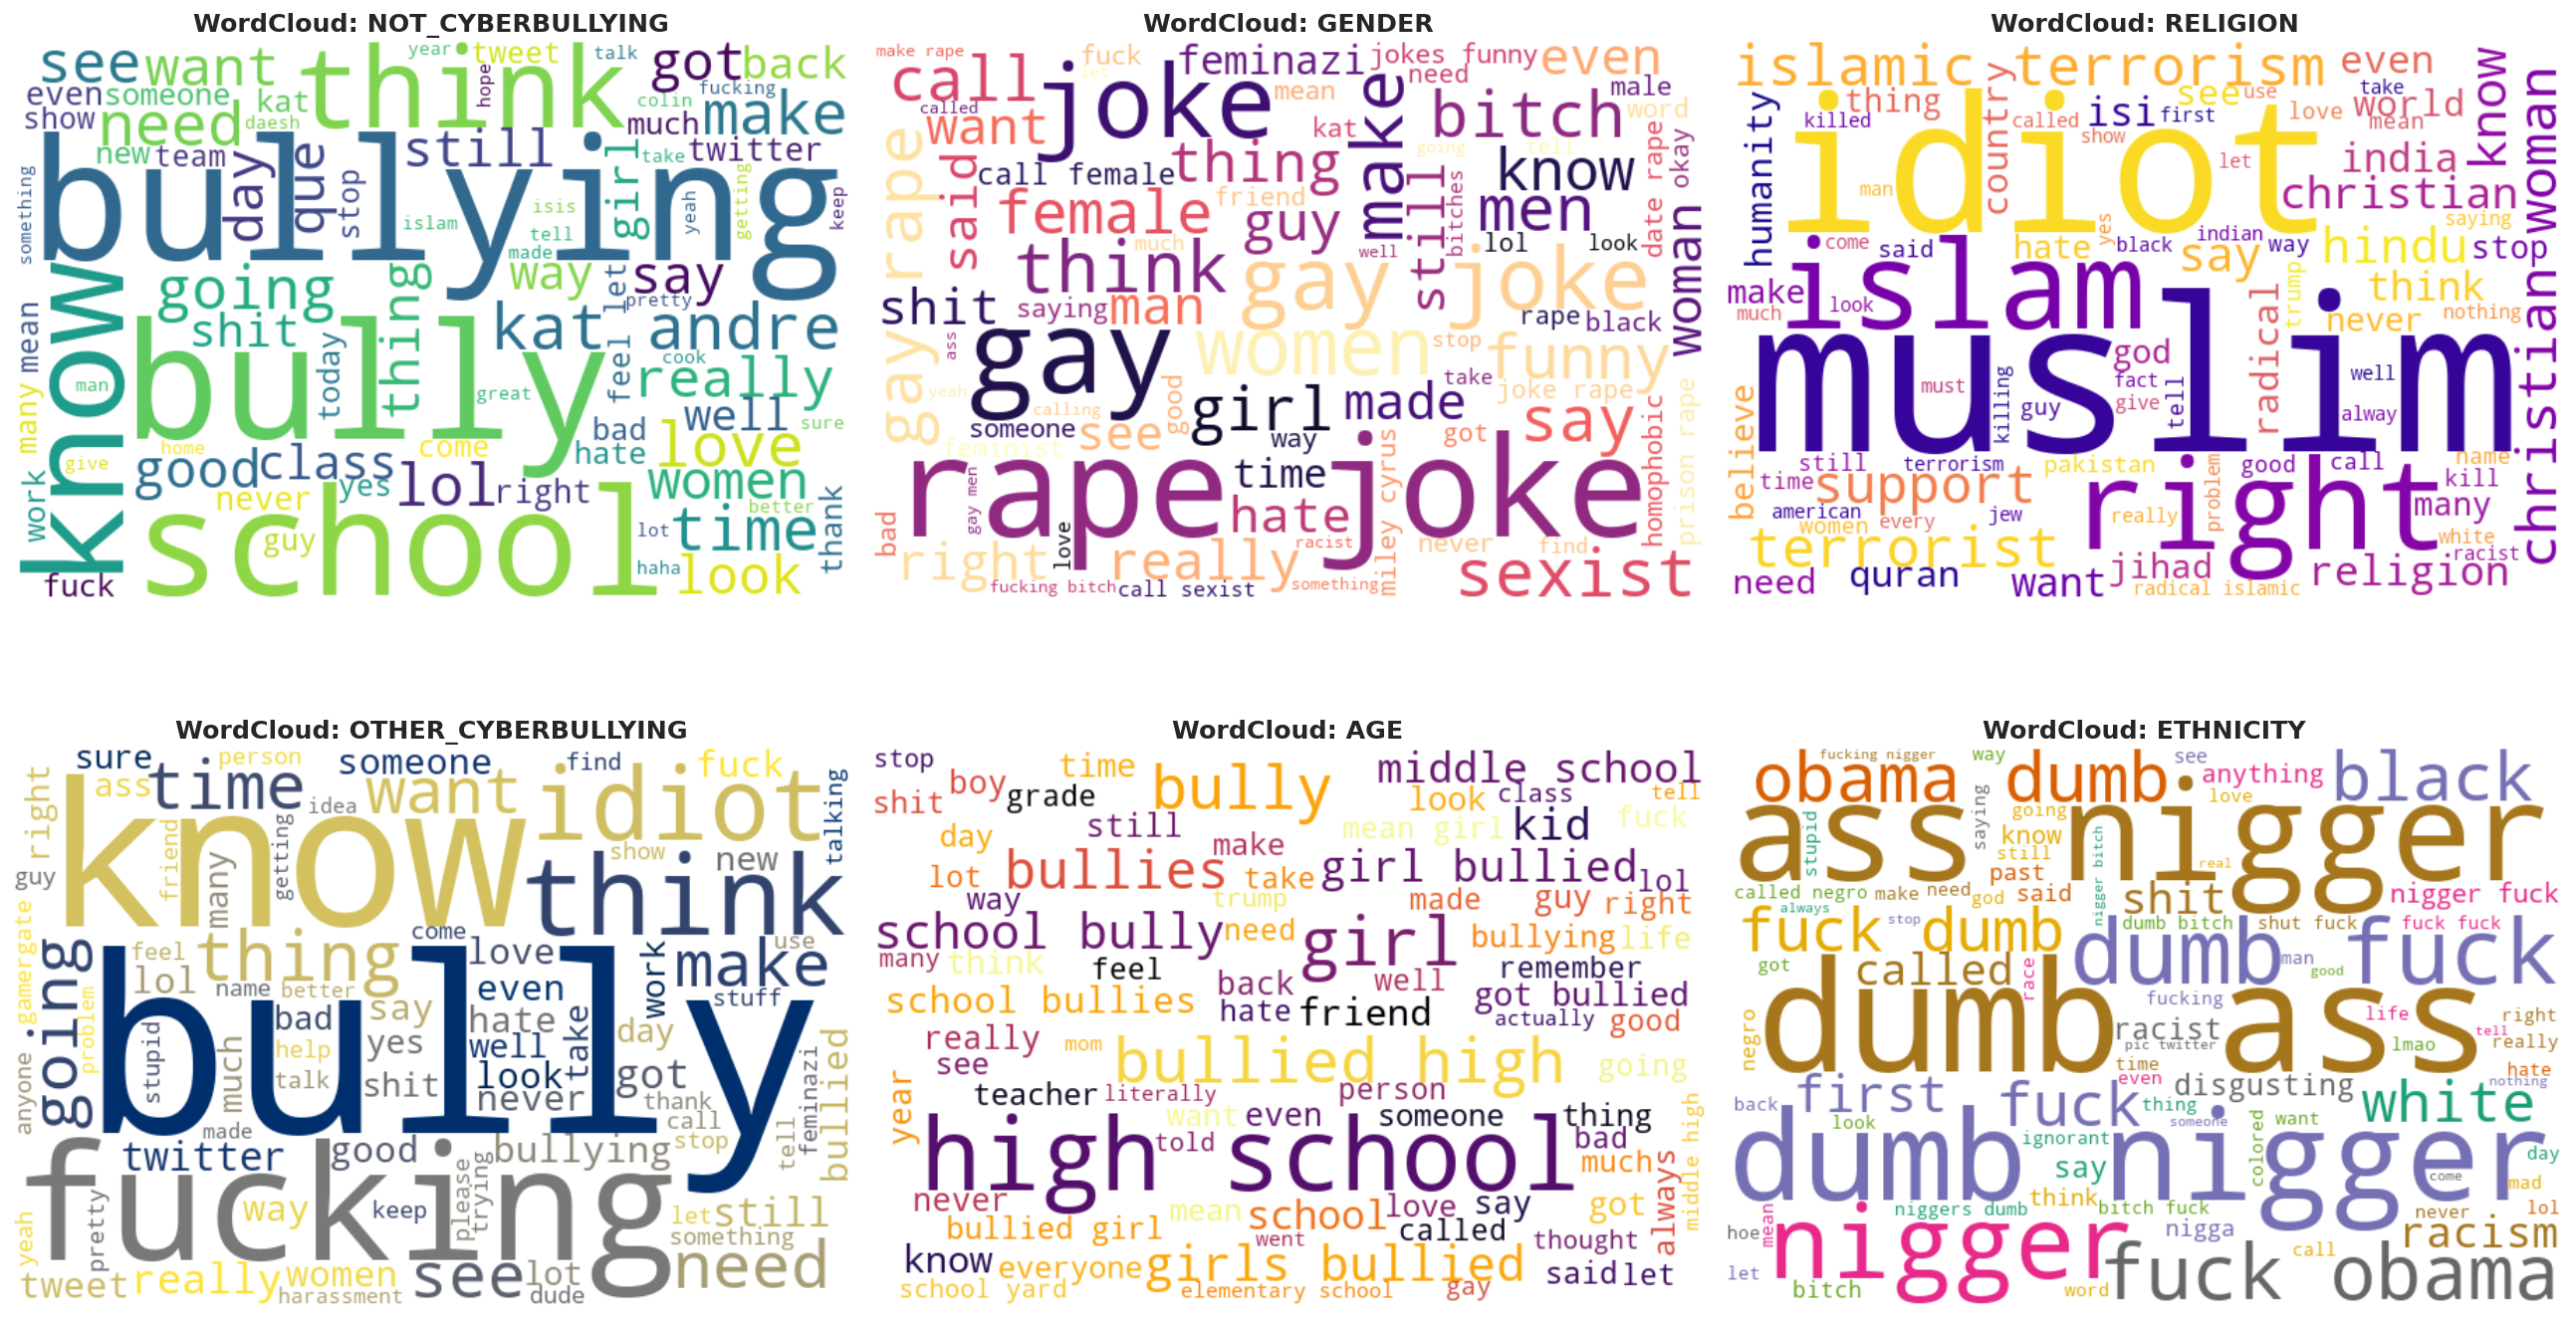

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

cmaps = ['viridis', 'magma', 'plasma', 'cividis', 'inferno', 'Dark2']

for i, cat in enumerate(categories):
    cat_text = " ".join(df_kaggle[df_kaggle['cyberbullying_type'] == cat]['tweet_text'].apply(lambda x: " ".join(clean_and_tokenize(x))))
    wc = WordCloud(width=600, height=400, background_color='white', colormap=cmaps[i], max_words=80).generate(cat_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"WordCloud: {cat.upper()}", fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 3.6 Explainability Preview: TF-IDF + Logistic Regression Feature Importance
Before deploying deep transformer models (like MuRIL / RoBERTa), training a linear baseline model (**TF-IDF + Logistic Regression**) allows us to inspect the learned `.coef_` weights.

**Why this matters for your project:**
- Each class receives positive coefficients for words that *increase* probability of that category, and negative coefficients for words that *decrease* it.
- This serves as an intuitive **feature attribution / explainability baseline** that directly previews what SHAP will do for our deep neural models!

In [10]:
# Prepare Train & Test splits
X = df_kaggle['tweet_text']
y = df_kaggle['cyberbullying_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english', min_df=3)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# Train Multinomial Logistic Regression
logreg = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
logreg.fit(X_train_vec, y_train)

# Evaluate Baseline
y_pred = logreg.predict(X_test_vec)
print("=" * 65)
print("📊 BASELINE MODEL PERFORMANCE (TF-IDF + LOGISTIC REGRESSION)")
print("=" * 65)
print(classification_report(y_test, y_pred, digits=4))

📊 BASELINE MODEL PERFORMANCE (TF-IDF + LOGISTIC REGRESSION)
                     precision    recall  f1-score   support

                age     0.9666    0.9768    0.9717      1598
          ethnicity     0.9727    0.9636    0.9681      1592
             gender     0.9093    0.8483    0.8777      1595
  not_cyberbullying     0.5968    0.5721    0.5842      1589
other_cyberbullying     0.6024    0.6786    0.6382      1565
           religion     0.9612    0.9450    0.9530      1600

           accuracy                         0.8314      9539
          macro avg     0.8348    0.8307    0.8322      9539
       weighted avg     0.8358    0.8314    0.8330      9539



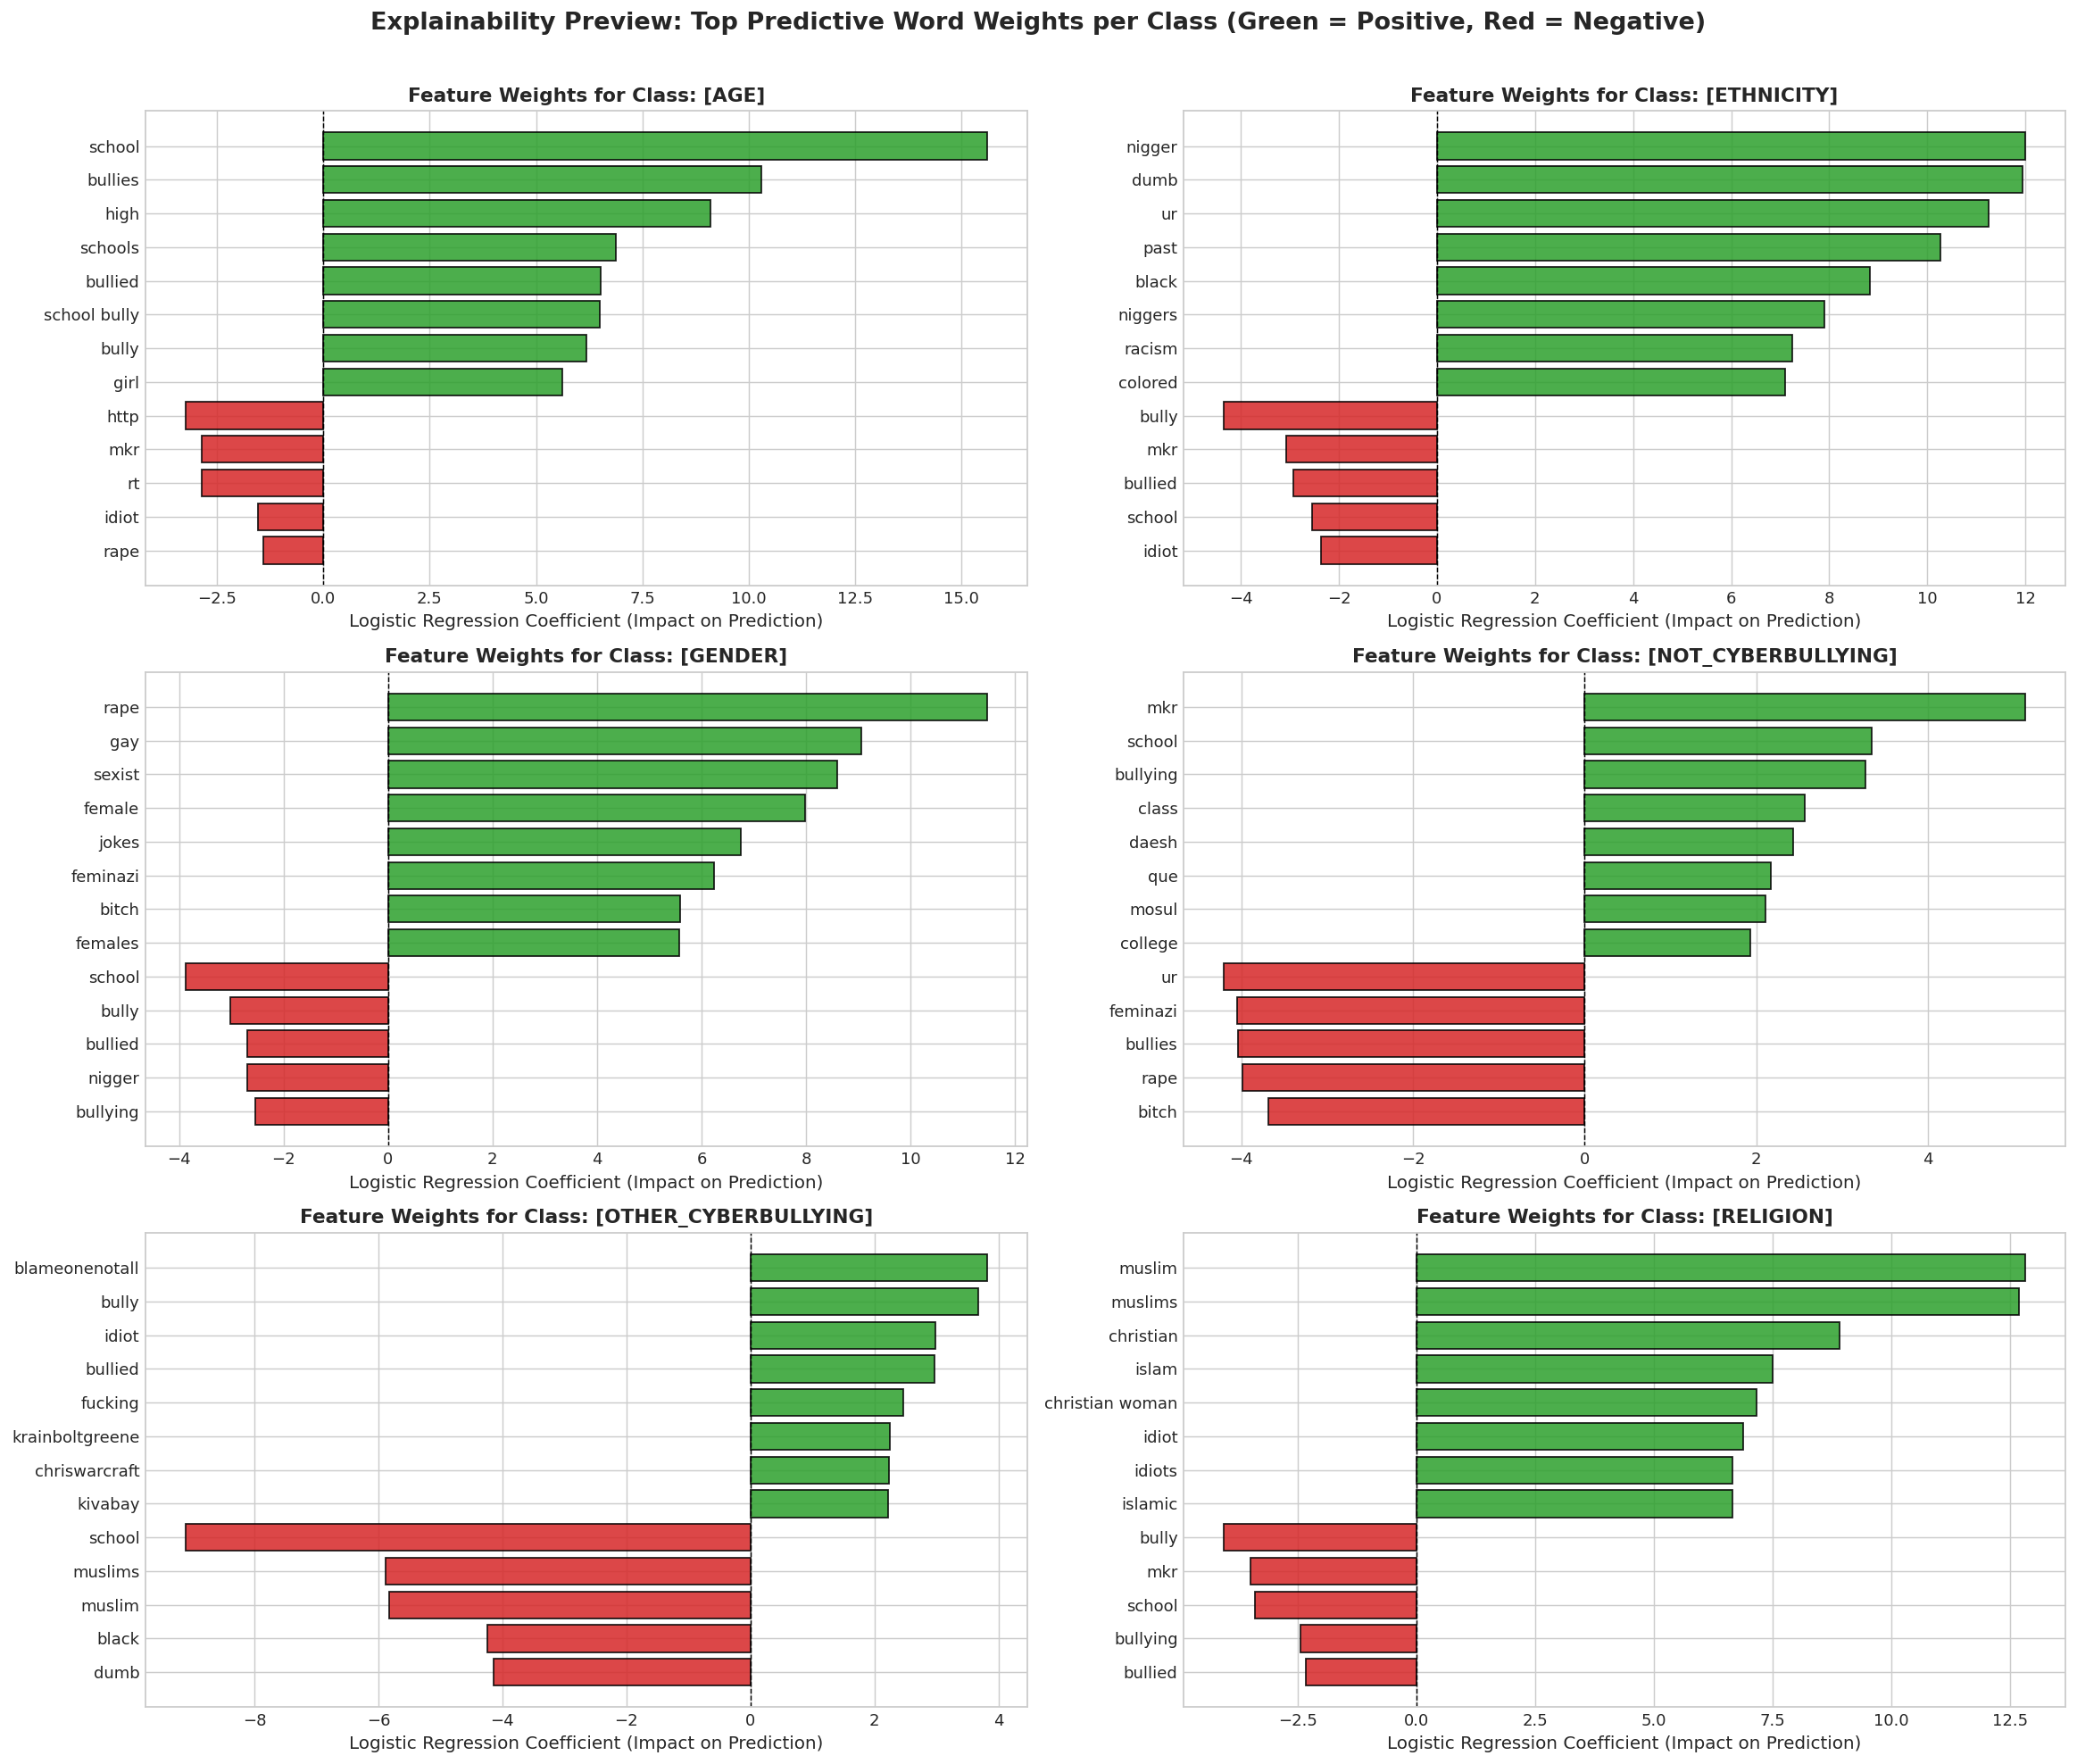

In [11]:
# Extract Top Positive and Negative Coefficients per Class
feature_names = np.array(tfidf.get_feature_names_out())
classes = logreg.classes_

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

for i, class_label in enumerate(classes):
    coefs = logreg.coef_[i]
    top_pos_idx = coefs.argsort()[-8:][::-1]
    top_neg_idx = coefs.argsort()[:5]
    
    selected_idx = np.concatenate([top_pos_idx, top_neg_idx])
    selected_words = feature_names[selected_idx]
    selected_weights = coefs[selected_idx]
    
    colors = ['#2ca02c' if w > 0 else '#d62728' for w in selected_weights]
    
    axes[i].barh(selected_words[::-1], selected_weights[::-1], color=colors[::-1], edgecolor='black', alpha=0.85)
    axes[i].set_title(f"Feature Weights for Class: [{class_label.upper()}]", fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Logistic Regression Coefficient (Impact on Prediction)")
    axes[i].axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.suptitle("Explainability Preview: Top Predictive Word Weights per Class (Green = Positive, Red = Negative)", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. BullyExplain Dataset: Hinglish & Multi-Dimensional Annotations
Now let us explore the **BullyExplain** dataset.  
Unlike standard English benchmarks, `BullyExplain` focuses on **Code-Mixed Hindi-English (Hinglish)** social media text and provides granular labels:
- `Bully_Label`: Binary classification (`Bully` vs `Non_bully`).
- `Emotion_label`: Emotional context (`Disgust`, `Joy`, `Ridicule`, `Anger`, etc.).
- `Target`: The target victim entity (`Religion`, `Relatives & Friends`, `Profession`, `Race`, `Gender`, etc.).
- `Sarcasm`: Whether the text uses sarcasm to mask bullying.
- **`Explaine`**: Ground-truth **word-level human rationales**, where annotators placed `{...}` around the exact toxic tokens.

Cleaned BullyExplain records: 6,393 (dropped 43 incomplete rows)


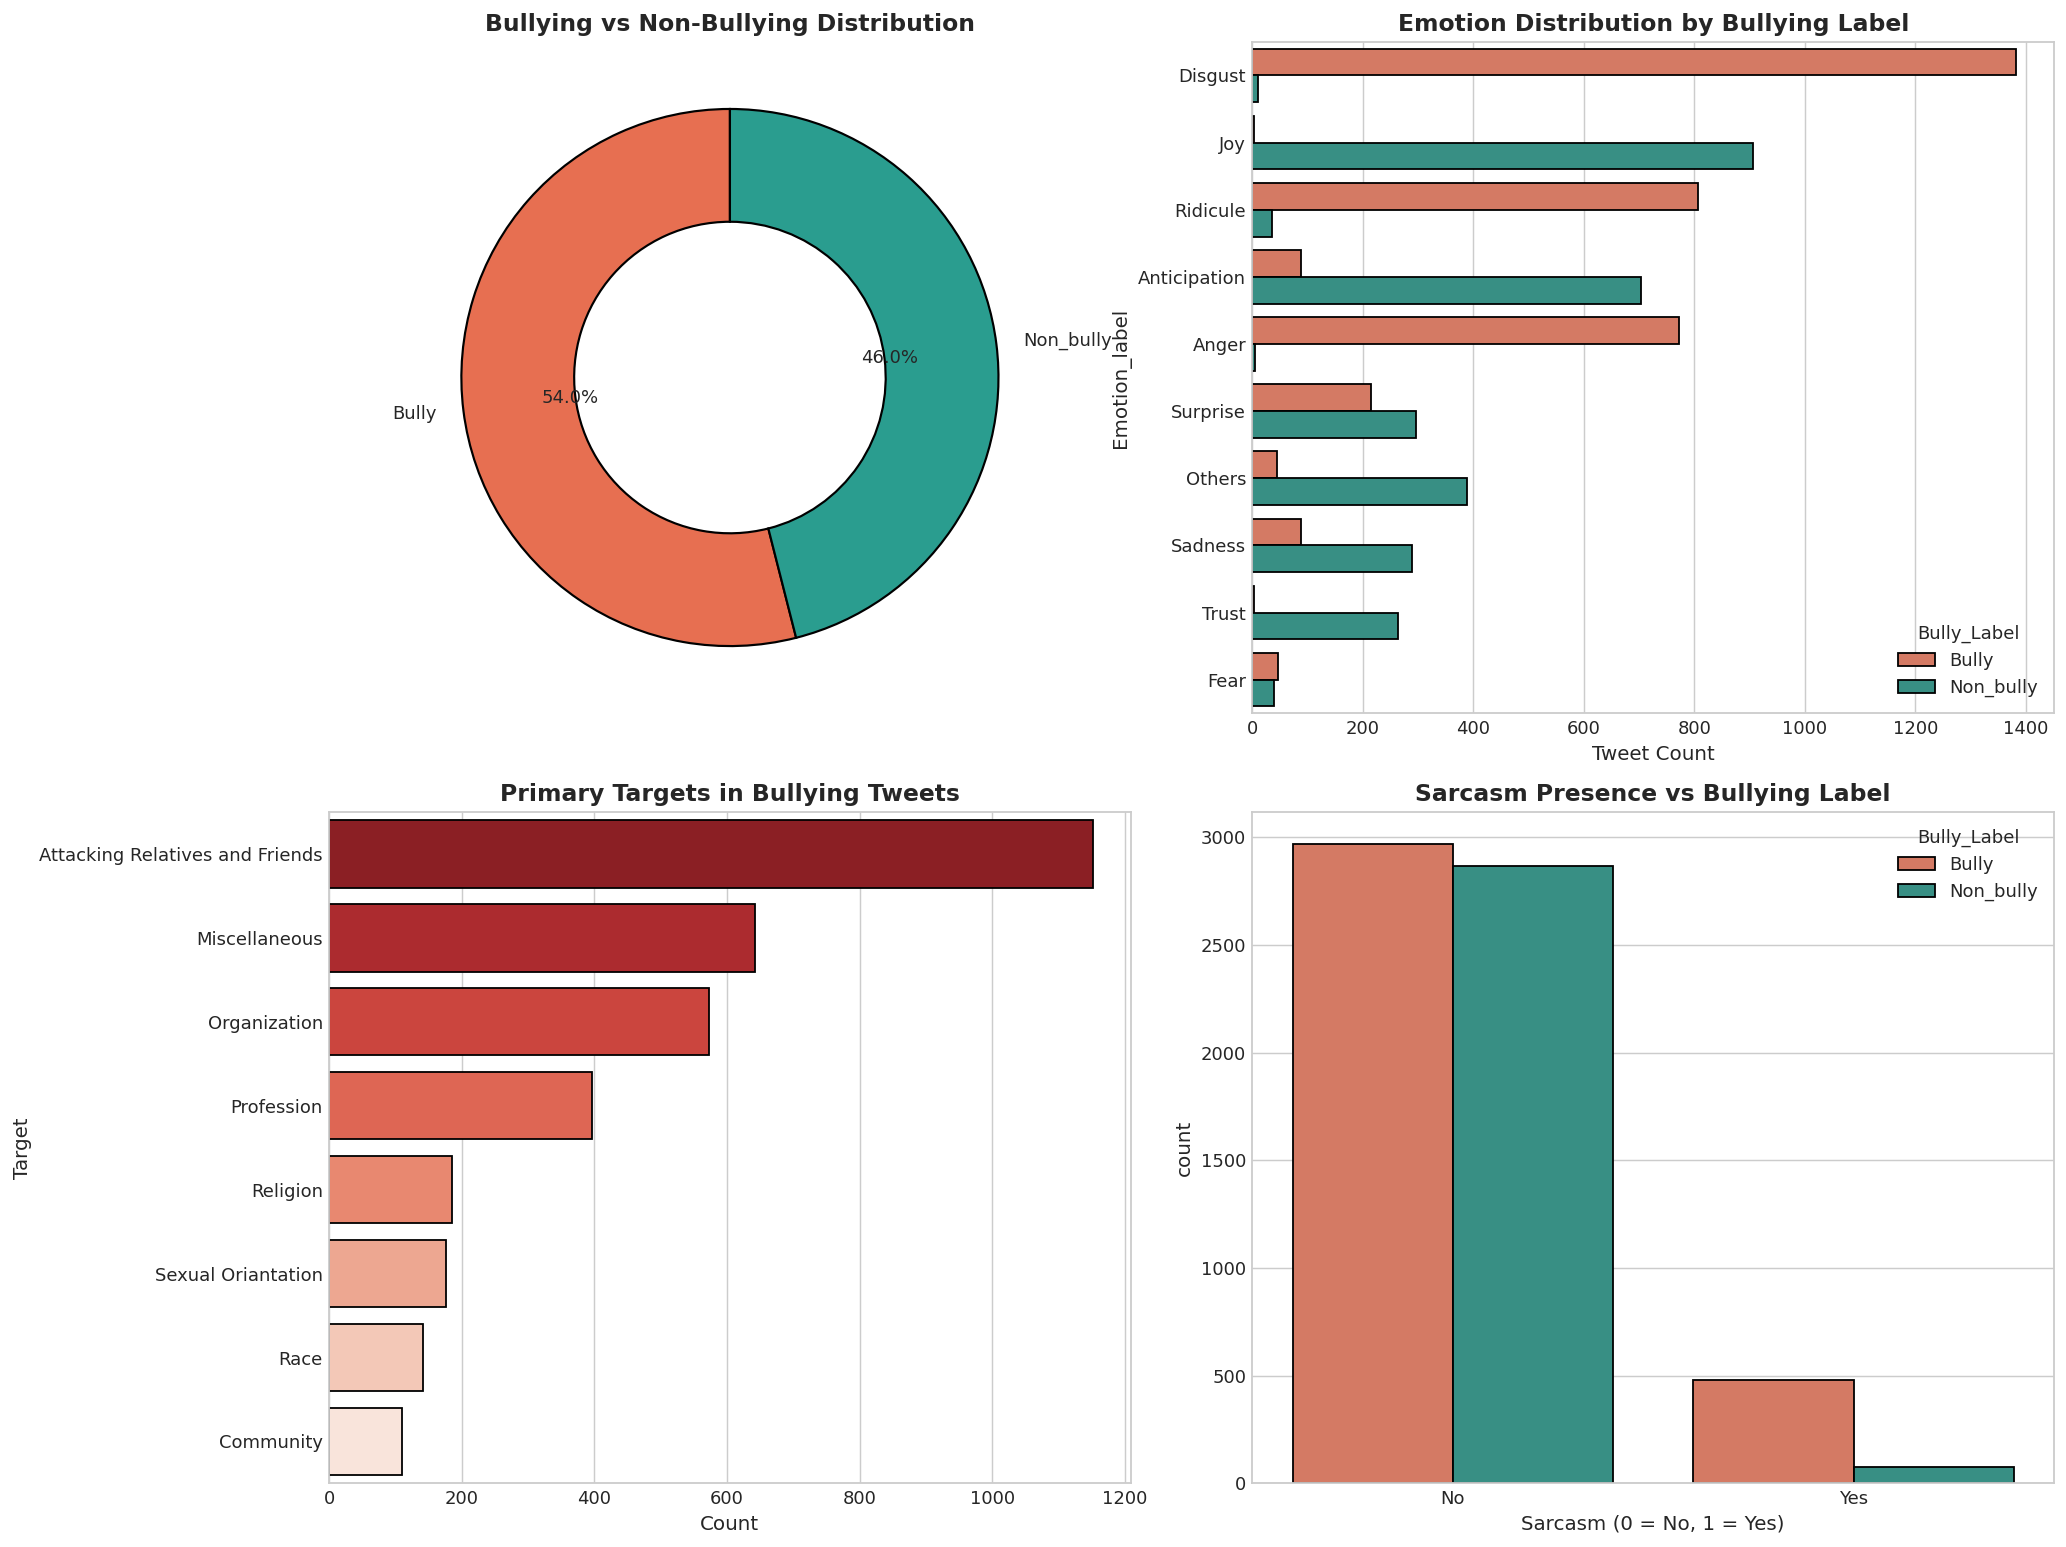

In [12]:
# Clean missing rows in Bully_Label if any
df_bully_clean = df_bully.dropna(subset=['Bully_Label', 'tweet']).copy()
print(f"Cleaned BullyExplain records: {len(df_bully_clean):,} (dropped {len(df_bully) - len(df_bully_clean)} incomplete rows)")

# Target & Label Distributions with rich visual styling
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Bully vs Non_bully distribution
bully_counts = df_bully_clean['Bully_Label'].value_counts()
axes[0, 0].pie(bully_counts, labels=bully_counts.index, autopct='%1.1f%%', colors=['#e76f51','#2a9d8f'],
               startangle=90, wedgeprops=dict(width=0.42, edgecolor='black', linewidth=1.2))
axes[0, 0].set_title("Bullying vs Non-Bullying Distribution", fontsize=13, fontweight='bold')

# 2. Emotion Breakdown across Bullying labels
sns.countplot(data=df_bully_clean, y='Emotion_label', hue='Bully_Label', ax=axes[0, 1], palette=['#e76f51','#2a9d8f'],
              order=df_bully_clean['Emotion_label'].value_counts().index, edgecolor='black')
axes[0, 1].set_title("Emotion Distribution by Bullying Label", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("Tweet Count")

# 3. Top Targets of Bullying
top_targets = df_bully_clean[df_bully_clean['Bully_Label'] == 'Bully']['Target'].value_counts().head(8)
sns.barplot(x=top_targets.values, y=top_targets.index, ax=axes[1, 0], palette='Reds_r', edgecolor='black')
axes[1, 0].set_title("Primary Targets in Bullying Tweets", fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel("Count")

# 4. Sarcasm vs Bullying
sns.countplot(data=df_bully_clean, x='Sarcasm', hue='Bully_Label', ax=axes[1, 1], palette=['#e76f51','#2a9d8f'], edgecolor='black')
axes[1, 1].set_title("Sarcasm Presence vs Bullying Label", fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel("Sarcasm (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()

### 4.2 Analyzing Ground-Truth Human Rationales (`Explaine`)
In `BullyExplain`, annotators marked abusive cues with curly braces (e.g. `{kuttiya`, `{randi}`, `{balatkar}`).  
Let us parse these rationales to understand:
1. What specific words annotators identified as bullying triggers.
2. How many words on average make up a bullying rationale.
3. Rationale density (proportion of tweet words flagged as harmful).

In [13]:
def extract_rationale_tokens(text):
    if not isinstance(text, str):
        return []
    # Extracts tokens prefixed or enclosed with curly braces
    matches = re.findall(r'\{([a-zA-Z0-9_ऀ-ॿ]+)', text)
    return [m.lower().strip() for m in matches if len(m.strip()) > 1]

df_bully_clean['rationale_tokens'] = df_bully_clean['Explaine'].apply(extract_rationale_tokens)
df_bully_clean['rationale_count'] = df_bully_clean['rationale_tokens'].apply(len)
df_bully_clean['tweet_word_count'] = df_bully_clean['tweet'].apply(lambda x: len(str(x).split()))
df_bully_clean['rationale_density'] = df_bully_clean['rationale_count'] / (df_bully_clean['tweet_word_count'] + 1e-5)

print("--- Rationale Statistics on Bully Tweets ---")
bully_only = df_bully_clean[df_bully_clean['Bully_Label'] == 'Bully']
print(f"Total Bullying Tweets with Rationales: {len(bully_only):,}")
print(f"Average Rationale Tokens per Bully Tweet: {bully_only['rationale_count'].mean():.2f}")
print(f"Average Rationale Density: {bully_only['rationale_density'].mean() * 100:.2f}% of tweet words are toxic rationales")

--- Rationale Statistics on Bully Tweets ---
Total Bullying Tweets with Rationales: 3,450
Average Rationale Tokens per Bully Tweet: 4.92
Average Rationale Density: 26.71% of tweet words are toxic rationales


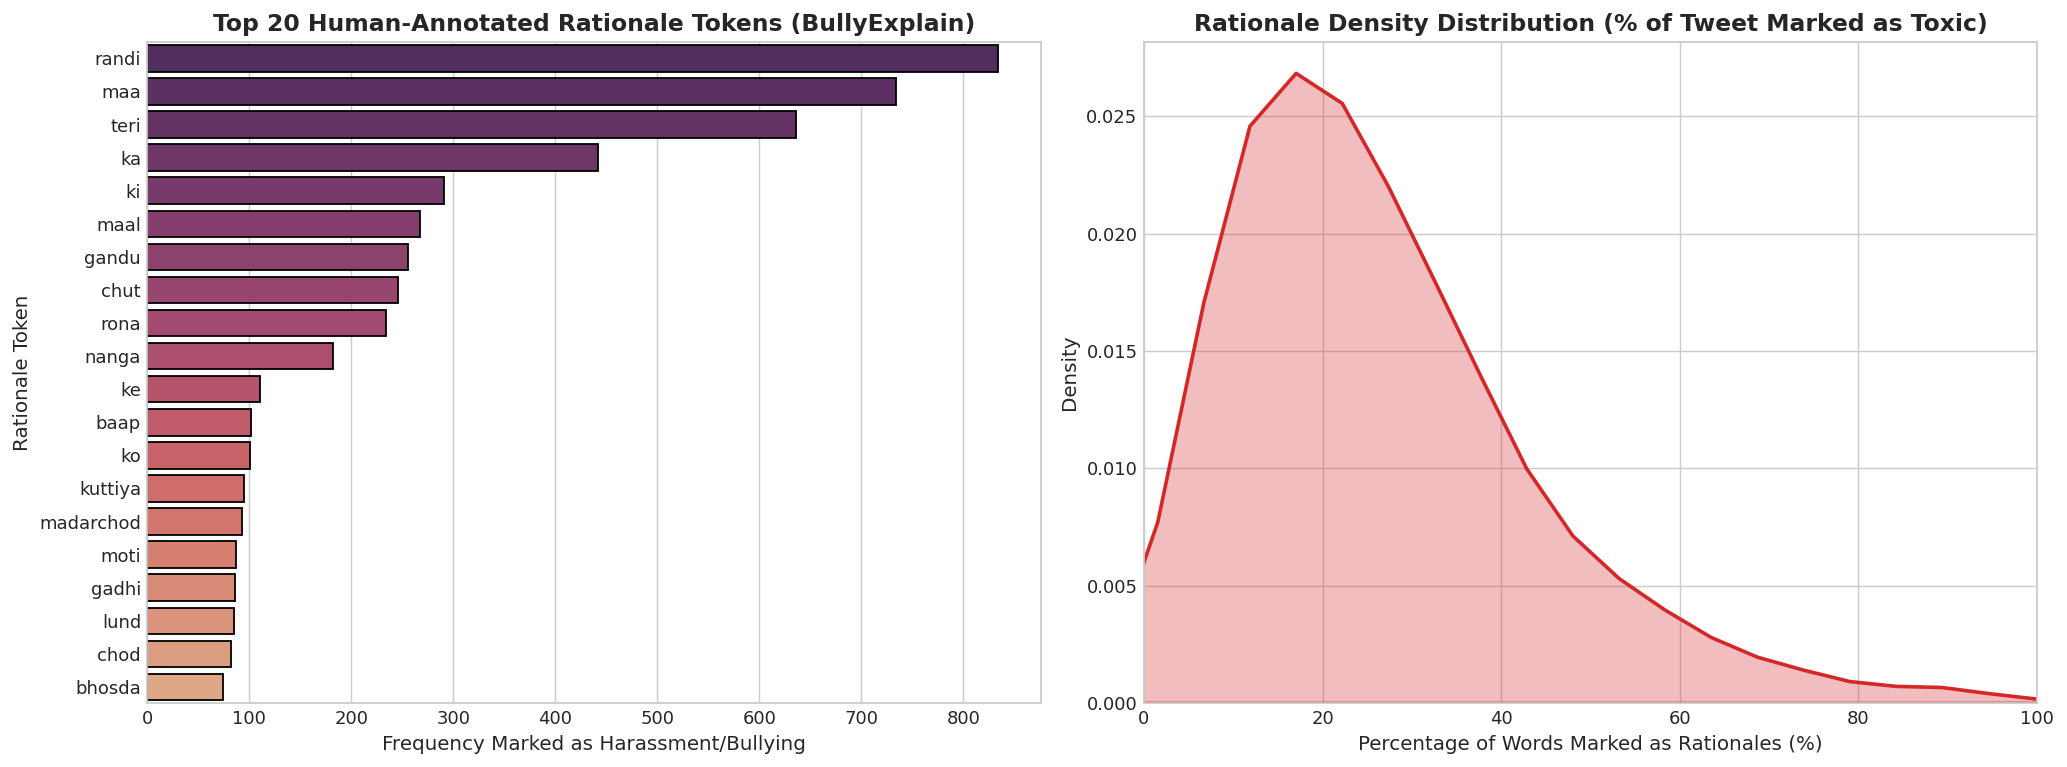

📝 SAMPLE GROUND-TRUTH HUMAN RATIONALES (EXPLAINE COLUMN)
Target: Attacking Relatives and Friends | Emotion: Anger
Raw Tweet: Ha to kisi or ka majak bana gandu sushant ka kyo bana ra h madarchod
Rationale: Ha to kisi or ka majak bana {gandu sushant ka kyo bana ra h {madarchod
--------------------------------------------------------------------------------
Target: Organization | Emotion: Disgust
Raw Tweet: @104off64 @BhuriaDa sare SRK fans aisa hi Randi rona karte h kya
Rationale: sare {SRK fans aisa hi {Randi {rona karte h kya
--------------------------------------------------------------------------------
Target: Profession | Emotion: Disgust
Raw Tweet: @suniketroy @ItsSBPA Bhai sirf dinner nahi sab meal mai vo hi khaate honge..Unke ghar ke har dabbe mai maal hi milega😂😂

#CompleteJustice4SSR
Rationale: Bhai sirf dinner nahi sab meal mai vo hi khaate honge Unke ghar ke har dabbe mai {maal hi {milega CompleteJustice4SSR
-------------------------------------------------------------------

In [14]:
# Top Rationale Words & Distribution Visualizations
all_rationales = [token for tokens in bully_only['rationale_tokens'] for token in tokens]
top_rationales = Counter(all_rationales).most_common(20)

words, counts = zip(*top_rationales)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot of top 20 rationale slurs
sns.barplot(x=list(counts), y=list(words), ax=ax1, palette="flare_r", edgecolor='black')
ax1.set_title("Top 20 Human-Annotated Rationale Tokens (BullyExplain)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Frequency Marked as Harassment/Bullying", fontsize=11)
ax1.set_ylabel("Rationale Token", fontsize=11)

# KDE of Rationale Density (% of words per tweet that are abusive)
sns.kdeplot(bully_only['rationale_density'] * 100, ax=ax2, fill=True, color='#d62728', alpha=0.3, linewidth=2)
ax2.set_title("Rationale Density Distribution (% of Tweet Marked as Toxic)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Percentage of Words Marked as Rationales (%)")
ax2.set_ylabel("Density")
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.show()

# Sample Rationale Highlighting Demonstration
print("=" * 80)
print("📝 SAMPLE GROUND-TRUTH HUMAN RATIONALES (EXPLAINE COLUMN)")
print("=" * 80)
samples = bully_only[['tweet', 'Explaine', 'Target', 'Emotion_label']].sample(3, random_state=42)
for idx, row in samples.iterrows():
    print(f"Target: {row['Target']} | Emotion: {row['Emotion_label']}")
    print(f"Raw Tweet: {row['tweet']}")
    print(f"Rationale: {row['Explaine']}")
    print("-" * 80)

## 5. Synthesis & Strategic Takeaways for Pipeline Development

---

### 📊 Comparative Summary Table

| Dimension | Kaggle Dataset (`cyberbullying_tweets.csv`) | BullyExplain Dataset (`BullyExplain.xlsx`) |
| :--- | :--- | :--- |
| **Total Samples** | 47,692 tweets | 6,436 tweets |
| **Language** | Primarily English | Code-Mixed Hinglish (Hindi + English) |
| **Task Type** | 6-Class Classification (`Age`, `Gender`, `Ethnicity`, `Religion`, `Other`, `Not_bullying`) | Binary (`Bully` vs `Non_bully`) + Multi-target + Emotion |
| **Explainability Support** | Implicit (via TF-IDF coefficients, SHAP, LIME token attributions) | Explicit Ground Truth (Word-level `{rationale}` annotations) |
| **Class Balance** | Perfectly Balanced (~16.6% per category) | Balanced (~53.6% Bully, ~45.7% Non-bully) |
| **Key Challenge** | Polysemy (e.g. school references in age vs normal talk) | Code-mixing, phonetic spellings, romanized Hindi slurs |

---

### 🛠️ Actionable Recommendations for Preprocessing (`02_preprocessing.ipynb`)
1. **Handle Mentions & URLs**:
   - In `cyberbullying_tweets.csv`, neutral `#MKR` tweets contain many `@user` tags. Replace URLs with `<URL>` tokens and decide whether to strip `@mentions` or normalize them to `<USER>`.
2. **Text Normalization**:
   - Remove trailing whitespace, decode HTML entities (`&amp;` $\rightarrow$ `&`), clean non-standard symbols.
3. **Casing Strategy**:
   - Keep case information or compute a shouting feature before lowercasing, as uppercase characters often convey aggression.
4. **Multilingual Tokenizer**:
   - Since BullyExplain contains Code-Mixed Hindi and Devanagari/Romanized Hindi, a multilingual model like **MuRIL (Multilingual Representations for Indian Languages)** or **XLM-RoBERTa** will outperform standard monolingual BERT.

---

### 🚀 Next Step in Pipeline
👉 Proceed to **`02_preprocessing.ipynb`** to implement reproducible text cleaning, tokenization pipelines, and train-validation-test data splits!